In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns


# Swarm plots with the z-score threshold for ranking

Saved: Swarm Plot of Non-CHX LOE z_score_of_test_stat for VTA1_99p5th_percentile.pdf


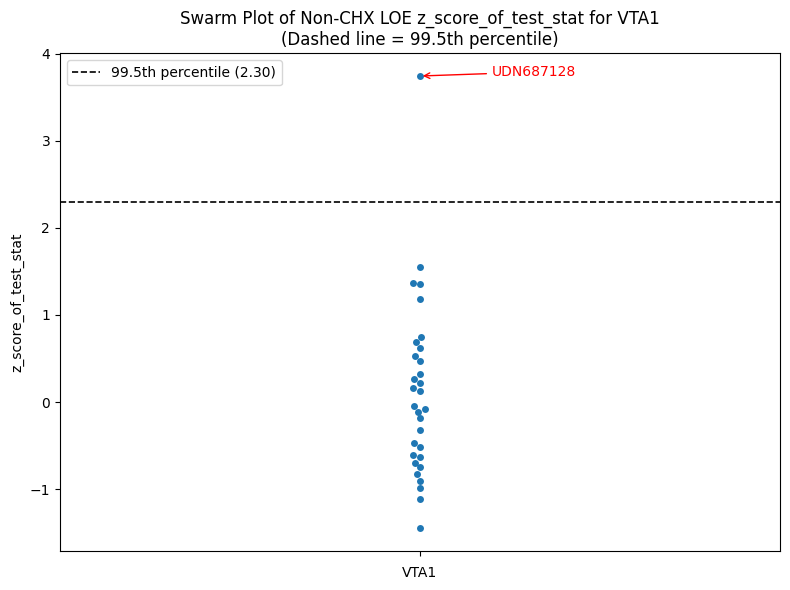

Saved: Swarm Plot of Non-CHX allelic imbalance z_score_of_test_stat for VTA1_99p5th_percentile.pdf


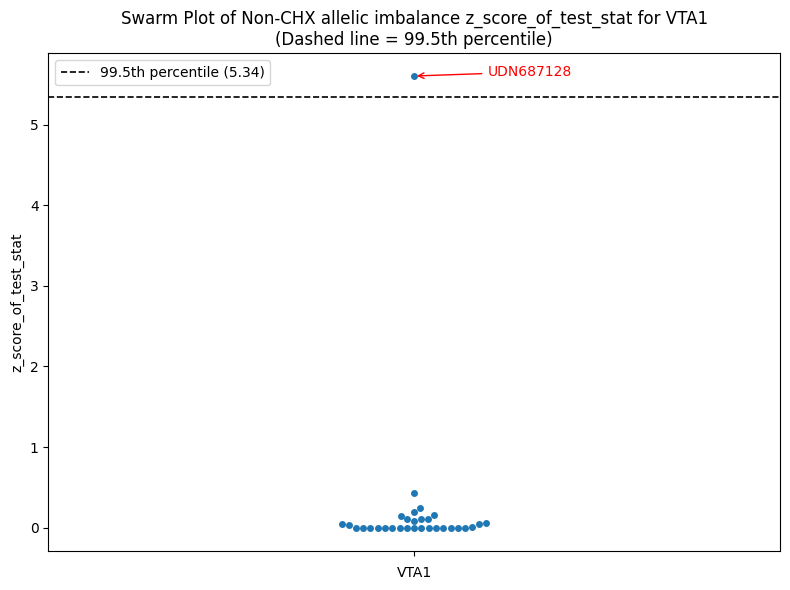

Saved: Swarm Plot of NMD rare steady state z_score_of_test_stat for MFN2_99p5th_percentile.pdf


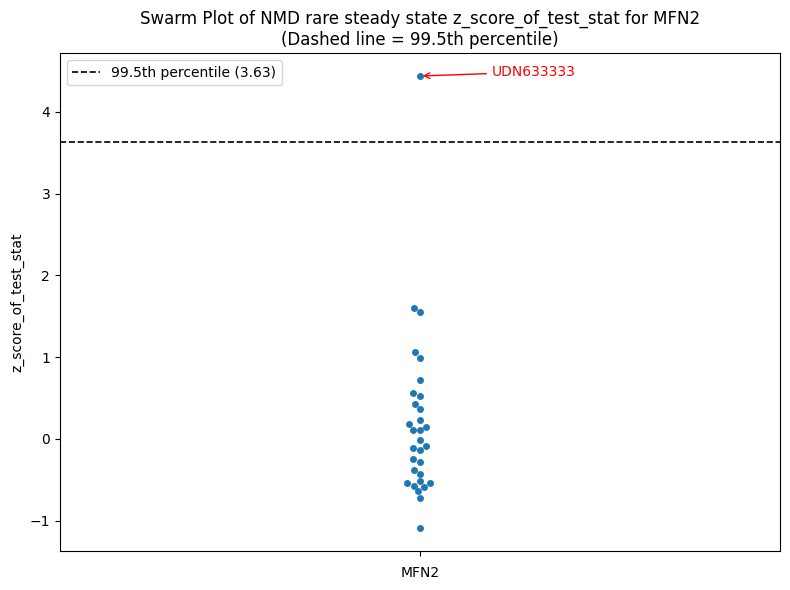

Saved: Swarm Plot of Non-CHX GOE z_score_of_test_stat for SET_99p5th_percentile.pdf


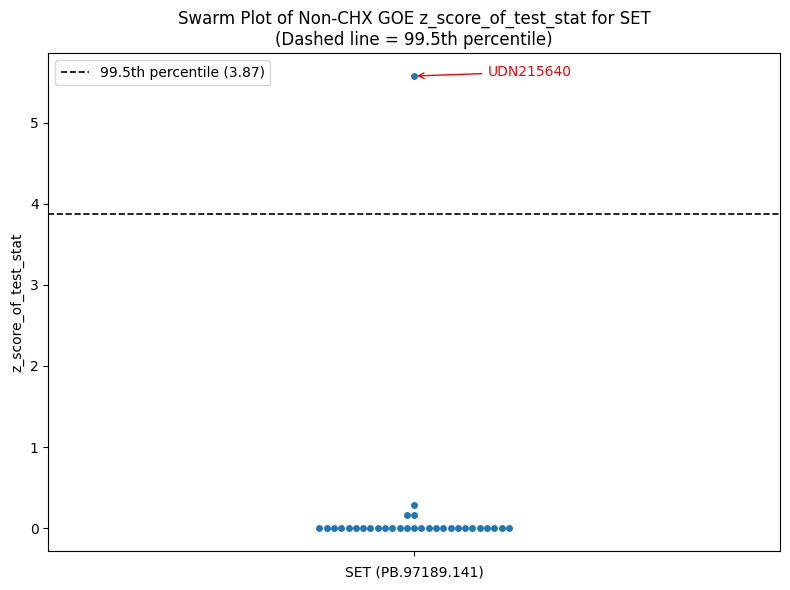

Saved: Swarm Plot of CHX GOE z_score_of_test_stat for SET_99p5th_percentile.pdf


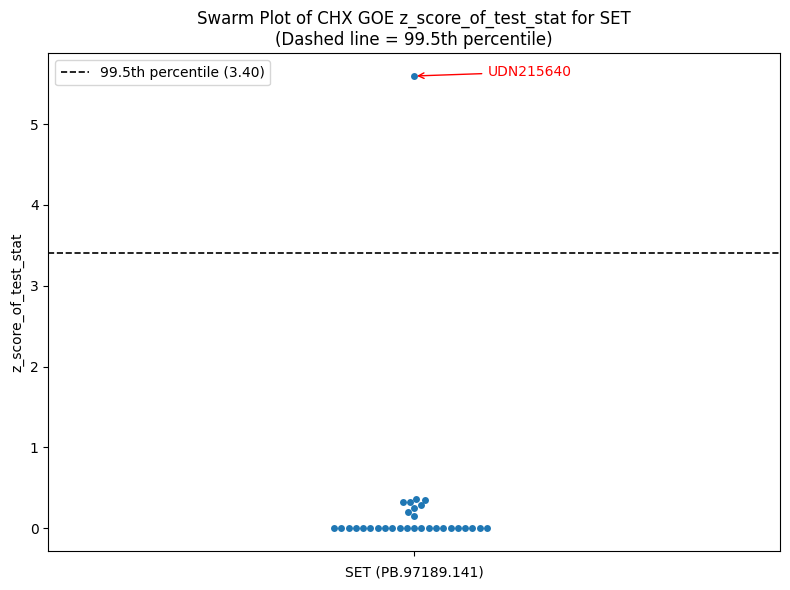

Saved: Swarm Plot of NMD rare steady state z_score_of_test_stat for HARS1_99p5th_percentile.pdf


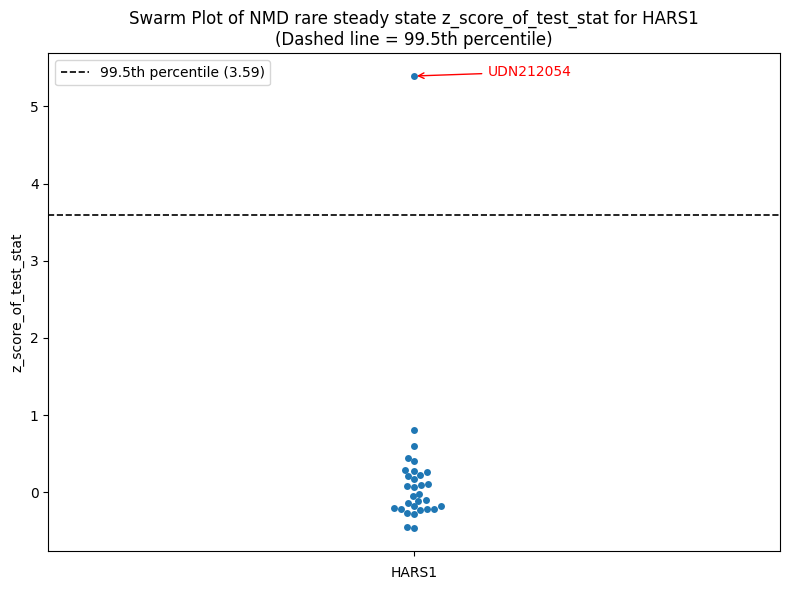

Saved: Swarm Plot of LOE z_score_of_test_stat for HARS1_99p5th_percentile.pdf


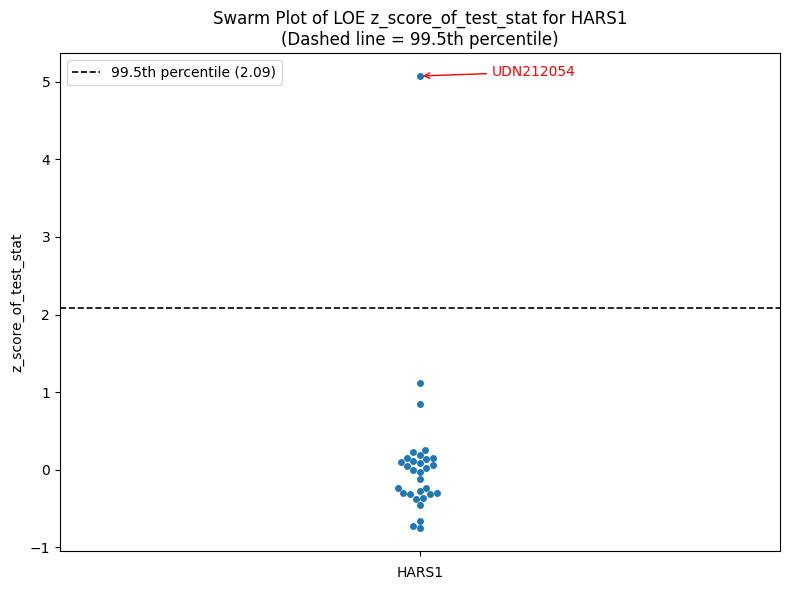

Saved: Swarm Plot of Non-CHX allelic imbalance z_score_of_test_stat for HARS1_99p5th_percentile.pdf


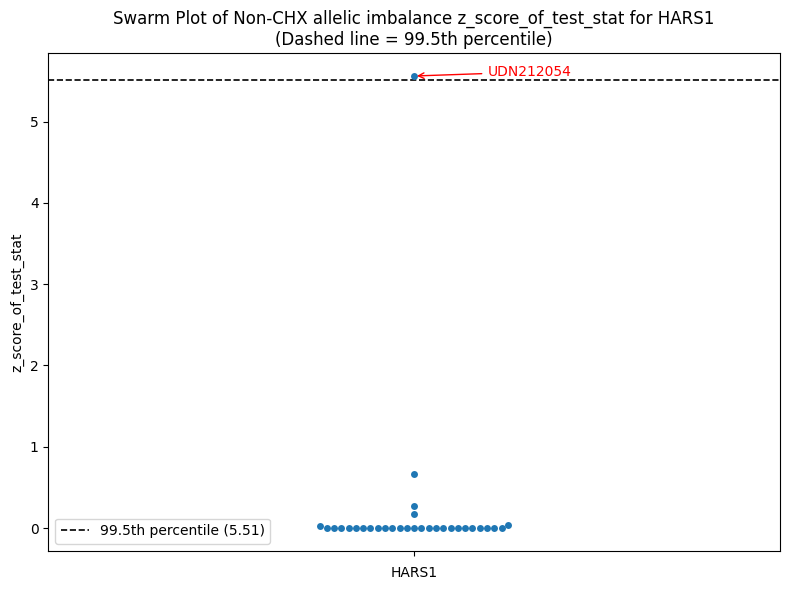

Saved: Swarm Plot of CHX allelic imbalance z_score_of_test_stat for HARS1_99p5th_percentile.pdf


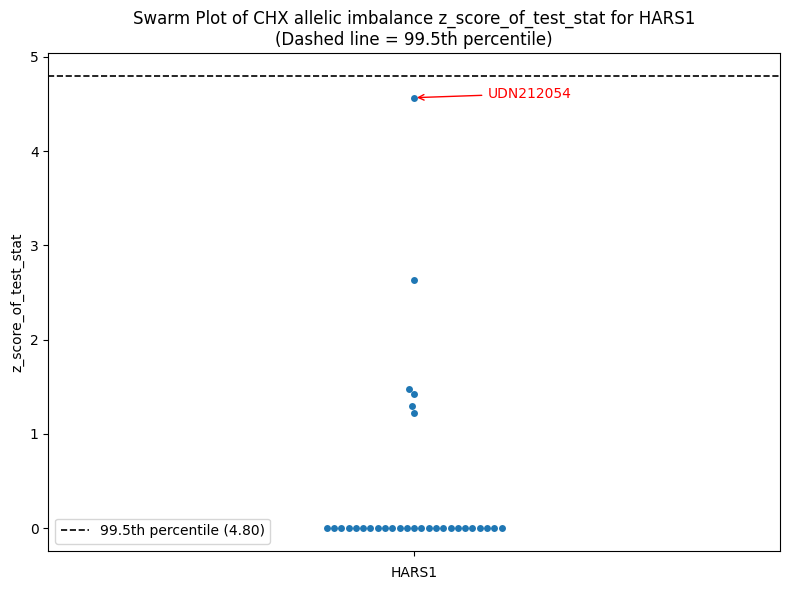

Saved: Swarm Plot of Non-CHX GOE z_score_of_test_stat for DND1_HARS1_99p5th_percentile.pdf


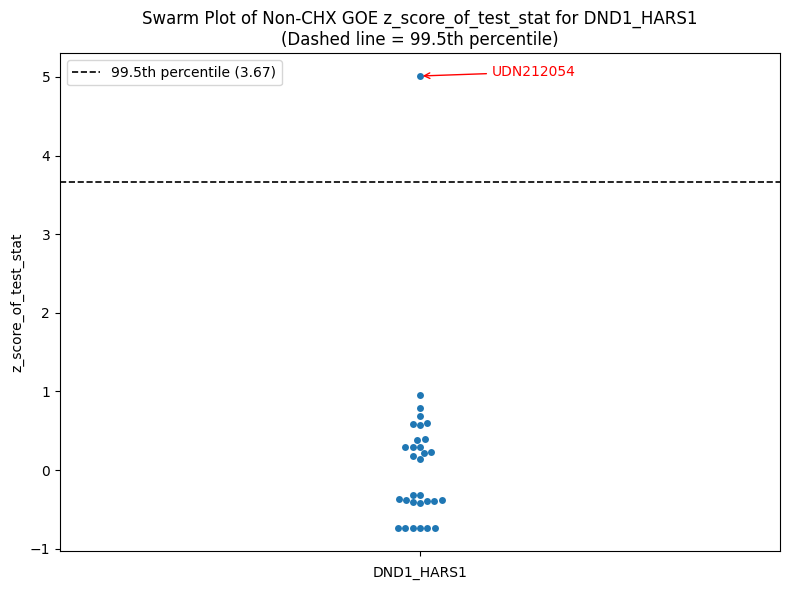

Saved: Swarm Plot of CHX GOE z_score_of_test_stat for DND1_HARS1_99p5th_percentile.pdf


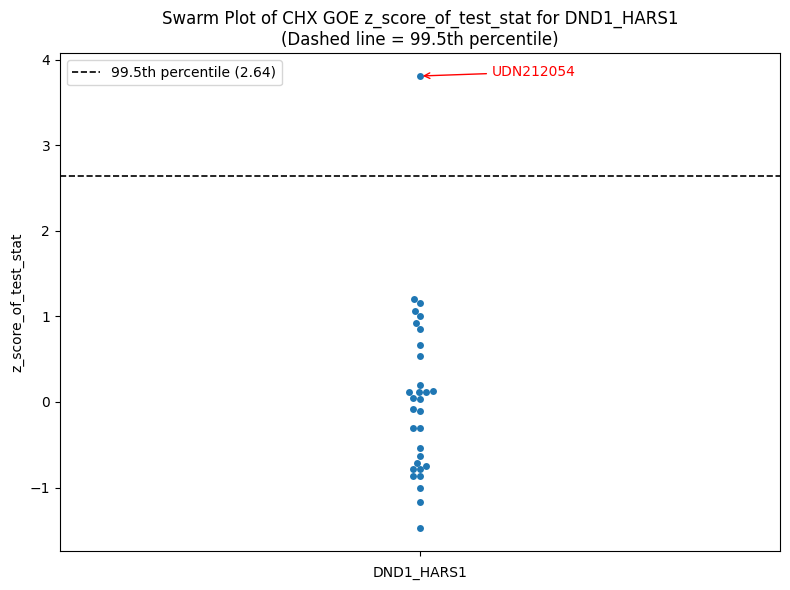

Saved: Swarm Plot of NMD rare steady state z_score_of_test_stat for SEC31A_99p5th_percentile.pdf


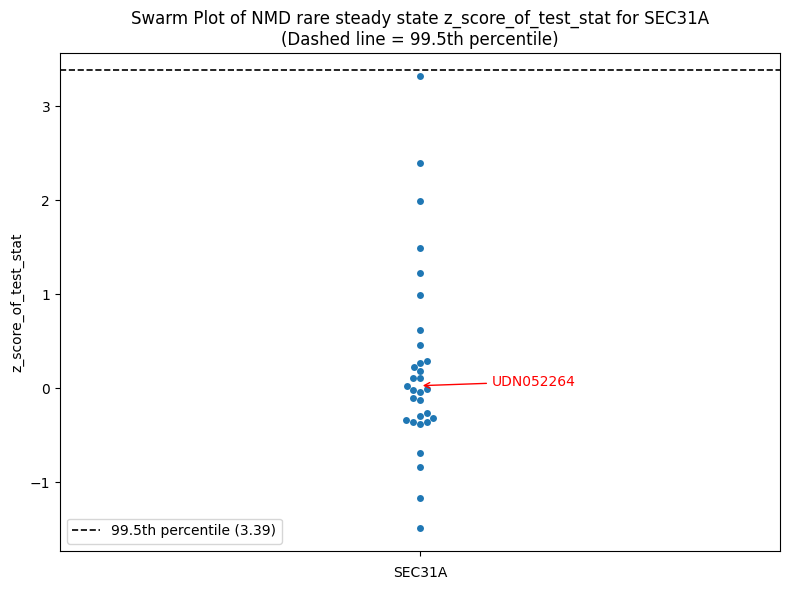

Saved: Swarm Plot of LOE z_score_of_test_stat for SEC31A_99p5th_percentile.pdf


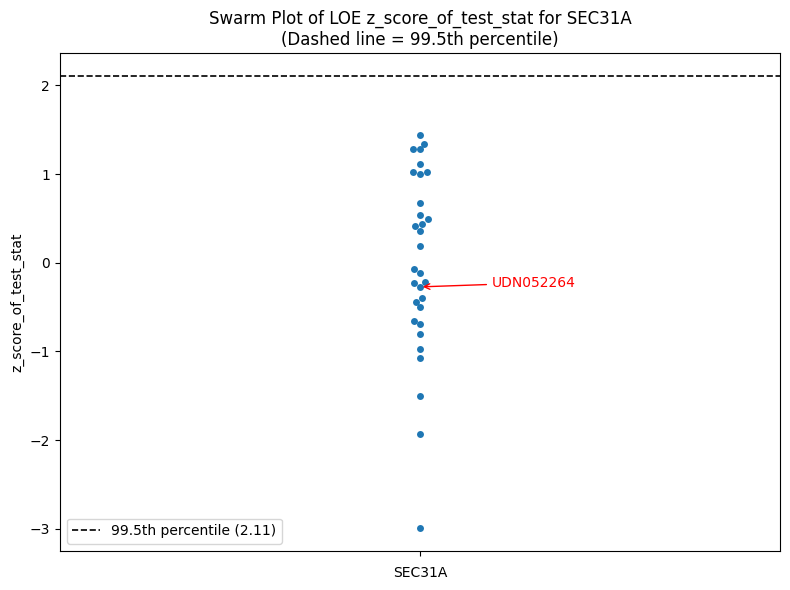

Saved: Swarm Plot of Non-CHX allelic imbalance z_score_of_test_stat for SEC31A_99p5th_percentile.pdf


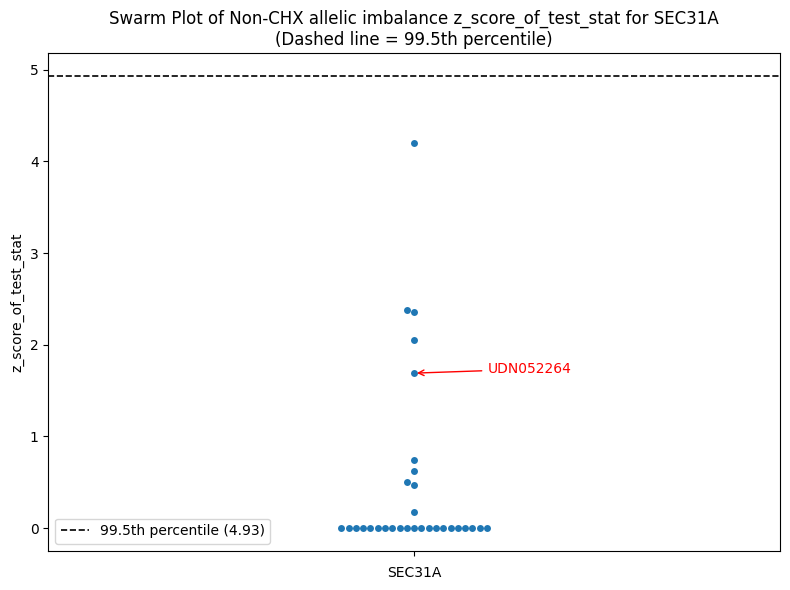

Saved: Swarm Plot of CHX allelic imbalance z_score_of_test_stat for SEC31A_99p5th_percentile.pdf


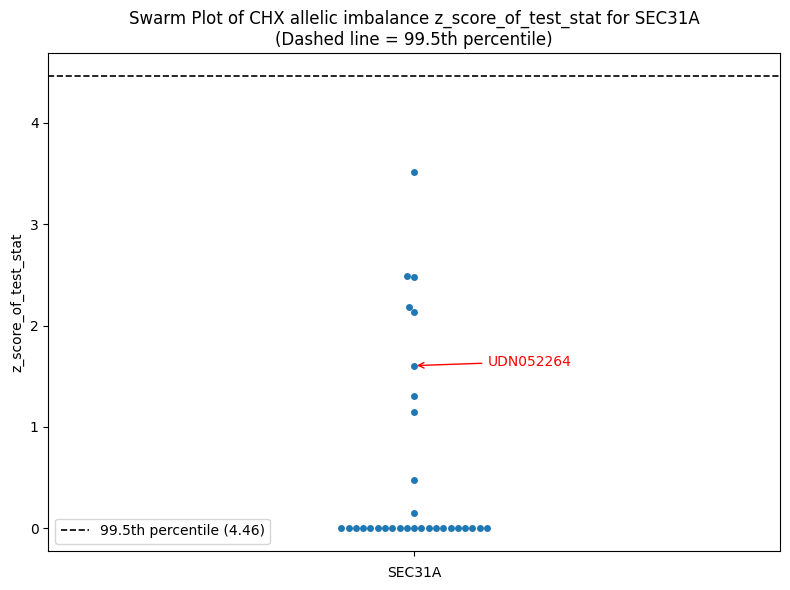

Saved: Swarm Plot of Non-CHX GOE z_score_of_test_stat for SEC31A_99p5th_percentile.pdf


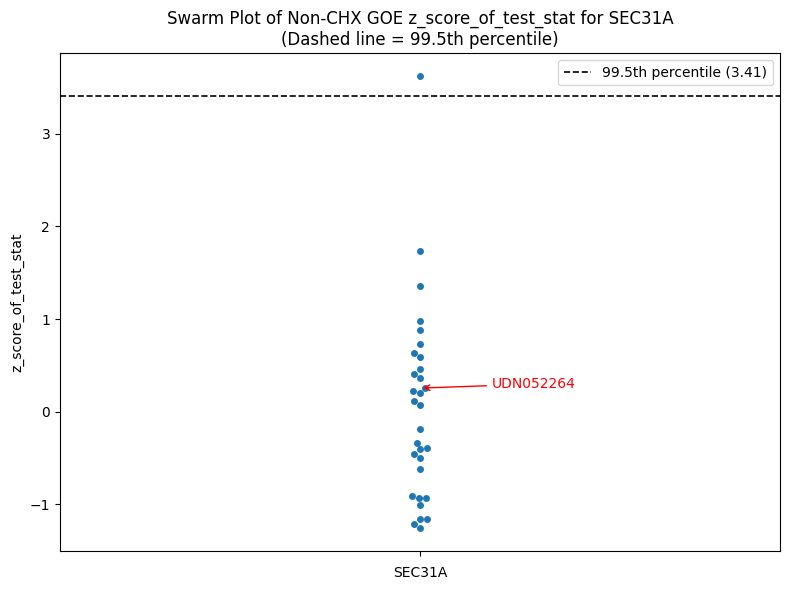

Saved: Swarm Plot of CHX GOE z_score_of_test_stat for SEC31A_99p5th_percentile.pdf


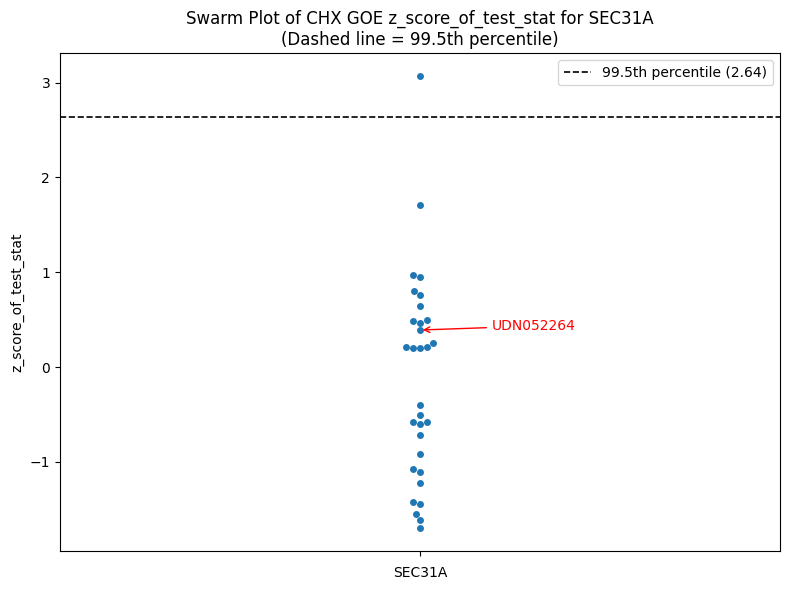

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ------------------------------
# Helper function
# ------------------------------
def swarm_with_percentile(df, subset_df, sample_id, label, title, output_basename, percentile=99.5):
    """Create a swarmplot with percentile dashed line and sample annotation."""
    plt.figure(figsize=(8, 6))
    ax = sns.swarmplot(data=subset_df, x=[""] * len(subset_df), y="z_score_of_test_stat")

    # Compute percentile
    sample_df = df[df["Sample"] == sample_id]
    if not sample_df.empty:
        percentile_value = np.percentile(sample_df["z_score_of_test_stat"], percentile)
        ax.axhline(percentile_value, color='black', linestyle='--', linewidth=1.2,
                   label=f'{percentile}th percentile ({percentile_value:.2f})')
        ax.legend()
    else:
        percentile_value = None

    # Annotate sample
    highlight = subset_df[subset_df["Sample"] == sample_id]
    if not highlight.empty:
        x_pos = 0
        y_val = highlight["z_score_of_test_stat"].values[0]
        ax.annotate(sample_id, xy=(x_pos, y_val), xytext=(x_pos + 0.1, y_val),
                    arrowprops=dict(arrowstyle="->", color='red'), color='red')

    ax.set_xlabel(label)
    ax.set_ylabel("z_score_of_test_stat")
    plt.title(f"{title}\n(Dashed line = {percentile}th percentile)")
    plt.tight_layout()

    percentile_str = f"{percentile}th_percentile".replace('.', 'p')
    output_file = f"{output_basename}_{percentile_str}.pdf"
    plt.savefig(output_file)
    print(f"Saved: {output_file}")
    plt.show()
    plt.close()


# ------------------------------
# Swarm plots
# ------------------------------

# In[6] Non-CHX LOE VTA1
df = pd.read_csv(
    '/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Command_line/9.7.25_iso_allele/Output/intermediate/Noncyclo_Expression_Outlier_LOE_gen_full_test_stat_and_z_scored_data.tsv.gz',
    sep="\t", compression='gzip')
subset = df[df["associated_gene"] == "VTA1"]
swarm_with_percentile(df, subset, "UDN687128", "VTA1",
                      "Swarm Plot of Non-CHX LOE z_score_of_test_stat for VTA1",
                      "Swarm Plot of Non-CHX LOE z_score_of_test_stat for VTA1")

# In[7] Non-CHX Allelic imbalance VTA1
df = pd.read_csv(
    '/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Command_line/9.7.25_iso_allele/Output/intermediate/Noncyclo_Allelic_Imbalance_gen_full_test_stat_and_z_scored_data.tsv.gz',
    sep="\t", compression='gzip')
subset = df[df["associated_gene"] == "VTA1"]
swarm_with_percentile(df, subset, "UDN687128", "VTA1",
                      "Swarm Plot of Non-CHX allelic imbalance z_score_of_test_stat for VTA1",
                      "Swarm Plot of Non-CHX allelic imbalance z_score_of_test_stat for VTA1")

# In[8] NMD rare steady state MFN2
df = pd.read_csv(
    '/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Command_line/9.7.25_iso_allele/Output/intermediate/NMD_rare_steady_state_transcript_gen_full_test_stat_and_z_scored_data.tsv.gz',
    sep="\t", compression='gzip')
subset = df[df["associated_gene"] == "MFN2"]
swarm_with_percentile(df, subset, "UDN633333", "MFN2",
                      "Swarm Plot of NMD rare steady state z_score_of_test_stat for MFN2",
                      "Swarm Plot of NMD rare steady state z_score_of_test_stat for MFN2")

# In[9] Non-CHX GOE SET isoform
df = pd.read_csv(
    '/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Command_line/9.7.25_iso_allele/Output/intermediate/Noncyclo_Expression_Outlier_GOE_iso_full_test_stat_and_z_scored_data.tsv.gz',
    sep="\t", compression='gzip')
subset = df[df["Isoform"] == "PB.97189.141"]
swarm_with_percentile(df, subset, "UDN215640", "SET (PB.97189.141)",
                      "Swarm Plot of Non-CHX GOE z_score_of_test_stat for SET",
                      "Swarm Plot of Non-CHX GOE z_score_of_test_stat for SET")

# In[10] CHX GOE SET isoform
df = pd.read_csv(
    '/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Command_line/9.7.25_iso_allele/Output/intermediate/Cyclo_Expression_Outlier_GOE_iso_full_test_stat_and_z_scored_data.tsv.gz',
    sep="\t", compression='gzip')
subset = df[df["Isoform"] == "PB.97189.141"]
swarm_with_percentile(df, subset, "UDN215640", "SET (PB.97189.141)",
                      "Swarm Plot of CHX GOE z_score_of_test_stat for SET",
                      "Swarm Plot of CHX GOE z_score_of_test_stat for SET")

# In[11] NMD HARS1
df = pd.read_csv(
    '/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Command_line/9.7.25_iso_allele/Output/intermediate/NMD_rare_steady_state_transcript_gen_full_test_stat_and_z_scored_data.tsv.gz',
    sep="\t", compression='gzip')
subset = df[df["associated_gene"] == "HARS1"]
swarm_with_percentile(df, subset, "UDN212054", "HARS1",
                      "Swarm Plot of NMD rare steady state z_score_of_test_stat for HARS1",
                      "Swarm Plot of NMD rare steady state z_score_of_test_stat for HARS1")

# In[12] LOE HARS1
df = pd.read_csv(
    '/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Command_line/9.7.25_iso_allele/Output/intermediate/Noncyclo_Expression_Outlier_LOE_gen_full_test_stat_and_z_scored_data.tsv.gz',
    sep="\t", compression='gzip')
subset = df[df["associated_gene"] == "HARS1"]
swarm_with_percentile(df, subset, "UDN212054", "HARS1",
                      "Swarm Plot of LOE z_score_of_test_stat for HARS1",
                      "Swarm Plot of LOE z_score_of_test_stat for HARS1")

# In[13] Non-CHX Allelic imbalance HARS1
df = pd.read_csv(
    '/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Command_line/9.7.25_iso_allele/Output/intermediate/Noncyclo_Allelic_Imbalance_gen_full_test_stat_and_z_scored_data.tsv.gz',
    sep="\t", compression='gzip')
subset = df[df["associated_gene"] == "HARS1"]
swarm_with_percentile(df, subset, "UDN212054", "HARS1",
                      "Swarm Plot of Non-CHX allelic imbalance z_score_of_test_stat for HARS1",
                      "Swarm Plot of Non-CHX allelic imbalance z_score_of_test_stat for HARS1")

# In[14] CHX Allelic imbalance HARS1
df = pd.read_csv(
    '/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Command_line/9.7.25_iso_allele/Output/intermediate/Cyclo_Allelic_Imbalance_gen_full_test_stat_and_z_scored_data.tsv.gz',
    sep="\t", compression='gzip')
subset = df[df["associated_gene"] == "HARS1"]
swarm_with_percentile(df, subset, "UDN212054", "HARS1",
                      "Swarm Plot of CHX allelic imbalance z_score_of_test_stat for HARS1",
                      "Swarm Plot of CHX allelic imbalance z_score_of_test_stat for HARS1")

# In[15] Non-CHX GOE DND1_HARS1
df = pd.read_csv(
    '/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Command_line/9.7.25_iso_allele/Output/intermediate/Noncyclo_Expression_Outlier_GOE_gen_full_test_stat_and_z_scored_data.tsv.gz',
    sep="\t", compression='gzip')
subset = df[df["associated_gene"] == "DND1_HARS1"]
swarm_with_percentile(df, subset, "UDN212054", "DND1_HARS1",
                      "Swarm Plot of Non-CHX GOE z_score_of_test_stat for DND1_HARS1",
                      "Swarm Plot of Non-CHX GOE z_score_of_test_stat for DND1_HARS1")

# In[23] CHX GOE DND1_HARS1
df = pd.read_csv(
    '/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Command_line/9.7.25_iso_allele/Output/intermediate/Cyclo_Expression_Outlier_GOE_gen_full_test_stat_and_z_scored_data.tsv.gz',
    sep="\t", compression='gzip')
subset = df[df["associated_gene"] == "DND1_HARS1"]
swarm_with_percentile(df, subset, "UDN212054", "DND1_HARS1",
                      "Swarm Plot of CHX GOE z_score_of_test_stat for DND1_HARS1",
                      "Swarm Plot of CHX GOE z_score_of_test_stat for DND1_HARS1")

# In[17] NMD SEC31A
df = pd.read_csv(
    '/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Command_line/9.7.25_iso_allele/Output/intermediate/NMD_rare_steady_state_transcript_gen_full_test_stat_and_z_scored_data.tsv.gz',
    sep="\t", compression='gzip')
subset = df[df["associated_gene"] == "SEC31A"]
swarm_with_percentile(df, subset, "UDN052264", "SEC31A",
                      "Swarm Plot of NMD rare steady state z_score_of_test_stat for SEC31A",
                      "Swarm Plot of NMD rare steady state z_score_of_test_stat for SEC31A")

# In[18] LOE SEC31A
df = pd.read_csv(
    '/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Command_line/9.7.25_iso_allele/Output/intermediate/Noncyclo_Expression_Outlier_LOE_gen_full_test_stat_and_z_scored_data.tsv.gz',
    sep="\t", compression='gzip')
subset = df[df["associated_gene"] == "SEC31A"]
swarm_with_percentile(df, subset, "UDN052264", "SEC31A",
                      "Swarm Plot of LOE z_score_of_test_stat for SEC31A",
                      "Swarm Plot of LOE z_score_of_test_stat for SEC31A")

# In[19] Non-CHX Allelic imbalance SEC31A
df = pd.read_csv(
    '/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Command_line/9.7.25_iso_allele/Output/intermediate/Noncyclo_Allelic_Imbalance_gen_full_test_stat_and_z_scored_data.tsv.gz',
    sep="\t", compression='gzip')
subset = df[df["associated_gene"] == "SEC31A"]
swarm_with_percentile(df, subset, "UDN052264", "SEC31A",
                      "Swarm Plot of Non-CHX allelic imbalance z_score_of_test_stat for SEC31A",
                      "Swarm Plot of Non-CHX allelic imbalance z_score_of_test_stat for SEC31A")

# In[20] CHX Allelic imbalance SEC31A
df = pd.read_csv(
    '/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Command_line/9.7.25_iso_allele/Output/intermediate/Cyclo_Allelic_Imbalance_gen_full_test_stat_and_z_scored_data.tsv.gz',
    sep="\t", compression='gzip')
subset = df[df["associated_gene"] == "SEC31A"]
swarm_with_percentile(df, subset, "UDN052264", "SEC31A",
                      "Swarm Plot of CHX allelic imbalance z_score_of_test_stat for SEC31A",
                      "Swarm Plot of CHX allelic imbalance z_score_of_test_stat for SEC31A")

# In[21] Non-CHX GOE SEC31A
df = pd.read_csv(
    '/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Command_line/9.7.25_iso_allele/Output/intermediate/Noncyclo_Expression_Outlier_GOE_gen_full_test_stat_and_z_scored_data.tsv.gz',
    sep="\t", compression='gzip')
subset = df[df["associated_gene"] == "SEC31A"]
swarm_with_percentile(df, subset, "UDN052264", "SEC31A",
                      "Swarm Plot of Non-CHX GOE z_score_of_test_stat for SEC31A",
                      "Swarm Plot of Non-CHX GOE z_score_of_test_stat for SEC31A")

# In[22] CHX GOE SEC31A
df = pd.read_csv(
    '/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Command_line/9.7.25_iso_allele/Output/intermediate/Cyclo_Expression_Outlier_GOE_gen_full_test_stat_and_z_scored_data.tsv.gz',
    sep="\t", compression='gzip')
subset = df[df["associated_gene"] == "SEC31A"]
swarm_with_percentile(df, subset, "UDN052264", "SEC31A",
                      "Swarm Plot of CHX GOE z_score_of_test_stat for SEC31A",
                      "Swarm Plot of CHX GOE z_score_of_test_stat for SEC31A")
# The single point above the dashed line is not being ranked. Because that patient has a different z-score threshold that 
# is needed to rank genes within that patient. It so happens that the threshold for that patient is 3.9